# Timeseries Analysis: Ryiadh Temperature (2021 - 2023)

Subtitle: **How to handle time series data with ease**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Optional: Fetch data from API

We'll use [Free Weather API](https://open-meteo.com/) for historical weather from 1940 (no API key required).

- Use [Geocoding](https://open-meteo.com/en/docs/geocoding-api) to lookup the `latitude` and `longitude` of the city you want.

In [8]:
# Get weather data for Riyadh using Open-Meteo API (timeseries)
# Documentation: https://open-meteo.com/en/docs
# We'll fetch temperature and relative humidity, hourly, for Riyadh from 2021-01-01 to 2023-12-31

import urllib.parse

# Riyadh latitude and longitude:
latitude = 24.71
longitude = 46.68
start_date = "2021-01-01"
end_date = "2023-12-31"
timezone = "Asia/Riyadh"

# Compose the URL for the API request (CSV format to easily load into pandas)
base_url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m,relative_humidity_2m",
    "timezone": timezone,
    "format": "csv",
}
query_string = urllib.parse.urlencode(params, safe=",")
url = f"{base_url}?{query_string}"

In [ ]:
# Download the csv file and load it into a DataFrame
df = pd.read_csv(url, skiprows=2)

In [ ]:
from pathlib import Path

# Save the DataFrame as a csv file
file_path = Path("data") / "riyadh_weather_2021-2023.csv"
if file_path.exists():
    print(f"File {file_path} already exists")
else:
    df.to_csv(file_path, index=False)

## Load timeseries data

In [ ]:
# Read the csv file and load it into a DataFrame
weather = pd.read_csv(file_path, index_col='time', parse_dates=True)
weather

,temperature_2m (°C),relative_humidity_2m (%)
time,,
2021-01-01 00:00:00,13.8,55
2021-01-01 01:00:00,13.3,61
2021-01-01 02:00:00,12.4,69
2021-01-01 03:00:00,12.6,75
2021-01-01 04:00:00,12.6,76
...,...,...
2023-12-31 19:00:00,19.0,71
2023-12-31 20:00:00,18.1,75
2023-12-31 21:00:00,17.4,78


## Select by time index

In [12]:
temp_col = 'temperature_2m (°C)'
humid_col = 'relative_humidity_2m (%)'

t1 = '2021-01-01 00:00:00'
t2 = '2021-12-31 23:59:59'

weather.loc[t1:t2, temp_col]

time
2021-01-01 00:00:00    13.8
2021-01-01 01:00:00    13.3
2021-01-01 02:00:00    12.4
2021-01-01 03:00:00    12.6
2021-01-01 04:00:00    12.6
                       ... 
2021-12-31 19:00:00    14.4
2021-12-31 20:00:00    13.7
2021-12-31 21:00:00    12.9
2021-12-31 22:00:00    12.3
2021-12-31 23:00:00    11.9
Name: temperature_2m (°C), Length: 8760, dtype: float64

In [16]:
weather.index.dtype.type

numpy.datetime64

More information on the `DatetimeIndex` and the slicing by using strings is provided in the section on [time series indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-datetimeindex).

## Time Range

What is the start and end date of the time series data set we are working with?

In [110]:
print('time min:', weather.index.min())
print('time max:', weather.index.max())
print('time range:', weather.index.max() - weather.index.min())

time min: 2021-01-01 00:00:00
time max: 2023-12-31 23:00:00
time range: 1094 days 23:00:00


## Lowest and highest values

In [114]:
print('temperature min:', weather[temp_col].min())
print('temperature max:', weather[temp_col].max())
print('temperature mean:', weather[temp_col].mean().round(2))

temperature min: 0.6
temperature max: 46.0
temperature mean: 27.27


## Resample a time series to another frequency

A very powerful method on time series data with a datetime index, is the ability to [`resample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.resample.html#pandas.Series.resample "pandas.Series.resample") time series to another frequency (e.g., converting secondly data into 5-minutely data).

Let's aggregate the current hourly time series values to the monthly maximum value in each of the stations. 

In [129]:
weather_yearly = weather.resample("YS")

print("temperature min:")
print(weather_yearly[temp_col].min())
print()

print("temperature max:")
print(weather_yearly[temp_col].max())
print()

print("temperature mean:")
print(weather_yearly[temp_col].mean().round(2))
print()


temperature min:
time
2021-01-01    3.4
2022-01-01    0.6
2023-01-01    5.9
Freq: YS-JAN, Name: temperature_2m (°C), dtype: float64

temperature max:
time
2021-01-01    45.9
2022-01-01    46.0
2023-01-01    46.0
Freq: YS-JAN, Name: temperature_2m (°C), dtype: float64

temperature mean:
time
2021-01-01    27.53
2022-01-01    27.21
2023-01-01    27.06
Freq: YS-JAN, Name: temperature_2m (°C), dtype: float64



When defined, the frequency of the time series is provided by the `freq` attribute:

In [131]:
weather_yearly.freq

<YearBegin: month=1>

### Resample vs GroupBy

The [`resample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.resample.html#pandas.Series.resample "pandas.Series.resample") method is similar to a groupby operation:

- it provides a time-based grouping, by using a string (e.g. `M`, `5H`, …) that defines the target frequency (see [offset aliases overview table](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases)).
- it requires an aggregation function such as `mean`, `max`,…

While `groupby()` is general purpose, it only groups the timestamps that actually exist in your dataframe. It will **not** generate rows for missing dates. On the other hand, `resample()` creates continuous time bins. For example, if your data skips a Tuesday, `resample('D')` still creates a bin for it (typically filled with `NaN`, which you can back-fill or forward-fill later).

More details on the power of time series `resampling` is provided in the user guide section on [resampling](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-resampling).

## Plotting Timeseries Data

### Plot: Monthly Temperature

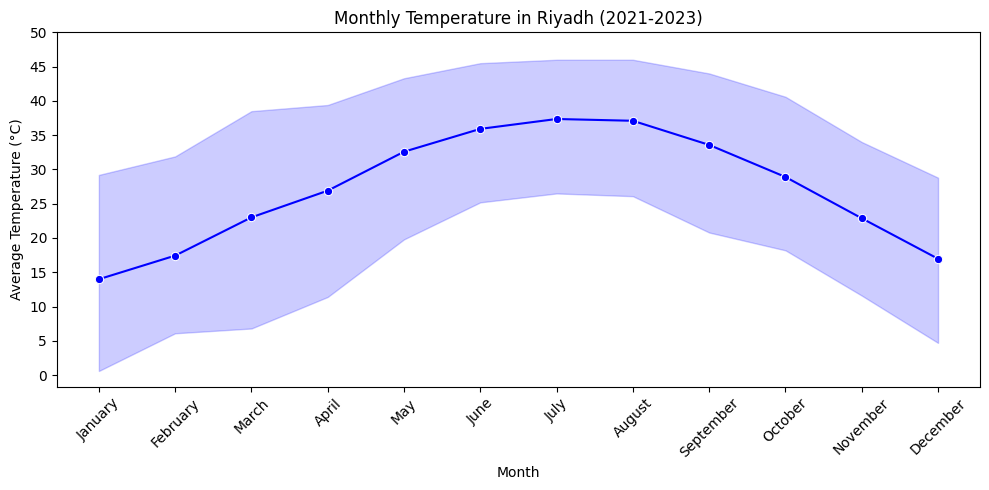

In [91]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    x=weather.index.month_name(), 
    y=weather[temp_col], 
    errorbar=lambda x: (x.min(), x.max()),
    marker="o", 
    color='blue',
    ax=ax
)

# Set x-tick labels to full month names
ax.tick_params(axis='x', labelrotation=45)
ax.set_yticks(range(0, 55, 5))

ax.set_xlabel('Month')
ax.set_ylabel('Average Temperature (°C)')
ax.set_title('Monthly Temperature in Riyadh (2021-2023)')
fig.tight_layout()

### Plot: Hourly Temperature

Let's look at a different time resolution: **hourly temperature**:

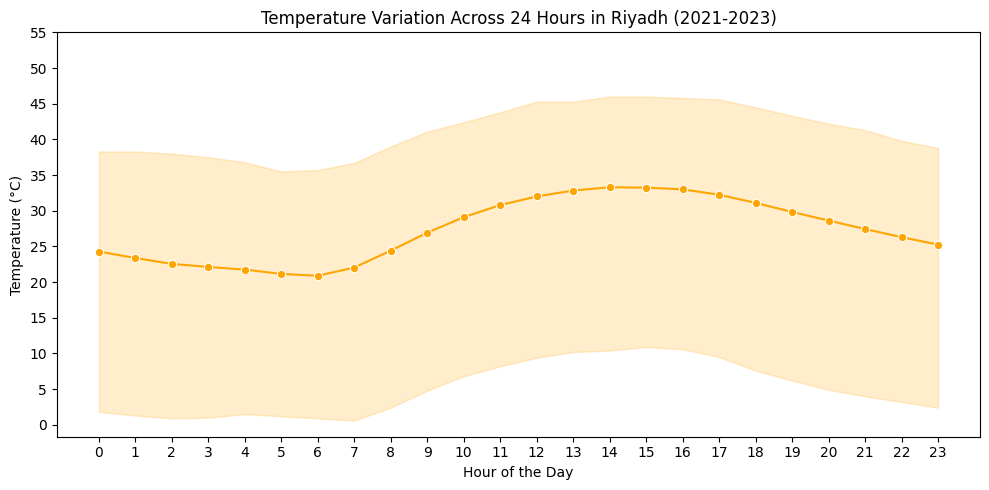

In [95]:
import seaborn as sns

fig, axs = plt.subplots(figsize=(10, 5))
sns.lineplot(
    x=weather.index.hour, 
    y=weather[temp_col],
    errorbar=lambda x: (x.min(), x.max()),
    marker="o",
    color='orange',
    ax=axs
)
axs.set_xlabel("Hour of the Day")
axs.set_ylabel("Temperature (°C)")
axs.set_title("Temperature Variation Across 24 Hours in Riyadh (2021-2023)")
axs.set_xticks(range(0, 24))
axs.set_yticks(range(0, 55 + 1,5))
fig.tight_layout()

### Plot: Hourly Temperature Per Season

We can get a better view if we split by the seasons, so we'll do just that:

In [ ]:
def month_to_season(month):
    # Seasons as typically experienced in Riyadh, Saudi Arabia (Middle East)
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8, 9]:
        return "Summer"
    else:  # October, November
        return "Autumn"
 
# Add "season" column to DataFrame
weather["season"] = weather.index.month.map(month_to_season)
weather

,temperature_2m (°C),relative_humidity_2m (%),season
time,,,
2021-01-01 00:00:00,13.8,55,Winter
2021-01-01 01:00:00,13.3,61,Winter
2021-01-01 02:00:00,12.4,69,Winter
2021-01-01 03:00:00,12.6,75,Winter
2021-01-01 04:00:00,12.6,76,Winter
...,...,...,...
2023-12-31 19:00:00,19.0,71,Winter
2023-12-31 20:00:00,18.1,75,Winter
2023-12-31 21:00:00,17.4,78,Winter


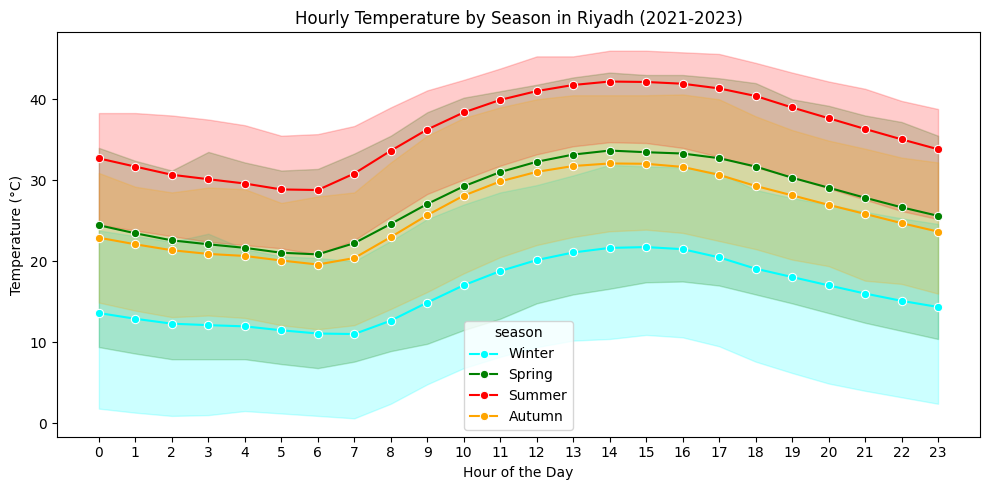

In [105]:
# Now you can plot with hue='season'
fig, ax = plt.subplots(figsize=(10, 5))

season_colors = {
    "Winter": "aqua",
    "Spring": "green",
    "Summer": "red",
    "Autumn": "orange",
}

sns.lineplot(
    x=weather.index.hour,
    y=weather[temp_col],
    hue=weather["season"],
    estimator="mean",  # get average temp per hour per season
    marker="o",
    errorbar=lambda x: (x.min(), x.max()),
    err_style='band',
    ax=ax,
    palette=season_colors
)
ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Hourly Temperature by Season in Riyadh (2021-2023)")
ax.set_xticks(range(0, 24))
fig.tight_layout()

---

References:

- A full overview on time series is given on the pages on [time series and date functionality](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries).